# Step 2 · Kinetic model

The Neu5Ac time courses from step 1 are described by a two-substrate Michaelis–Menten model
that contains the enzyme concentration, so `kcat` comes out directly:

$$v = \frac{k_{cat}\,[\mathrm{NeuS}]\,[\mathrm{ManNAc}]\,[\mathrm{PEP}]}{(K_{m,ManNAc} + [\mathrm{ManNAc}])\,(K_{m,PEP} + [\mathrm{PEP}])}$$

Instead of a single best-fit value per parameter we compute the **posterior distribution**:
the range of parameter values that is compatible with the data, given what we assumed before
looking at it (the **prior**). The sampler (Hamiltonian Monte Carlo, via Catalax) draws a few
thousand parameter sets from that distribution; their mean and spread are the result.

**Your decisions in this step:** the model, the priors, the assumed measurement noise, and
whether the posterior and the fit can be trusted.

In [1]:
# Setup. In Colab this installs the tools and downloads the workshop; locally it does nothing.
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("neus-workshop").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "chromhandler==0.10.11", "catalax==0.5.5"], check=True)
    subprocess.run(["git", "clone", "-q", "https://github.com/haeussma/neus-workshop", "neus-workshop"], check=True)
if Path("neus-workshop").exists():
    os.chdir("neus-workshop")

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

In [2]:
import time
import warnings

import catalax as ctx

ctx.enable_x64()  # must come before anything else in JAX: in 32-bit the sampler cannot resolve the posterior

import numpyro

NUM_CHAINS = 2
numpyro.set_host_device_count(NUM_CHAINS)  # one CPU "device" per chain, so the chains run in parallel; before any JAX computation

import arviz as az
import catalax.mcmc as cmc
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
import pandas as pd
from pyenzyme.versions.v2 import EnzymeMLDocument

warnings.filterwarnings("ignore")
print("JAX devices:", jax.local_device_count())

conditions = pd.read_csv(ROOT / "data" / "conditions.csv").set_index("sample_id")  # initial concentrations in mM
document = EnzymeMLDocument.model_validate_json((ROOT / "checkpoints" / "neus_enzymeml.json").read_text())
print(len(document.measurements), "measurements")

JAX devices: 2
24 measurements


## 1 · Dataset

Only Neu5Ac was measured. ManNAc and PEP start at their nominal concentrations: most ManNAc
samples (up to 100 mM) lie far outside the 1–5 mM calibration. Catalax compares every model
state with the data, so the unmeasured states get NaN arrays; NaN marks "no data point here"
and is skipped by the sampler.

In [3]:
measured = ctx.Dataset.from_enzymeml(document)  # Neu5Ac data only; kept for plotting
for m in measured.measurements:
    m.initial_conditions["ManNAc"] = float(conditions.loc[m.id, "ManNAc"])
    m.initial_conditions["PEP"] = float(conditions.loc[m.id, "PEP"])

dataset = measured.model_copy(deep=True)  # what the sampler gets
for m in dataset.measurements:
    for state in ("ManNAc", "PEP", "NeuS"):  # not measured
        m.data[state] = np.full(len(m.time), np.nan)

first = dataset.measurements[0]
print("data arrays:", list(first.data), "| time points per measurement:", len(first.time))
print("initial conditions of", first.id, "(mM):", first.initial_conditions)

data arrays: ['Neu5Ac', 'ManNAc', 'PEP', 'NeuS'] | time points per measurement: 6
initial conditions of MAN_A (mM): {'NeuS': 0.000414, 'Neu5Ac': 0.07885962043547136, 'ManNAc': 0.039, 'PEP': 20.0}


## 2 · Model and priors

Every state stays observable (the Catalax default); the NaN arrays decide which points count.
(`observable=False` looks like the right switch for unmeasured states, but in Catalax 0.5.5 it
silently breaks the sampler.)

A **prior** is what we assume about a parameter before seeing the data. Here every parameter
gets a log-uniform prior: every order of magnitude between the bounds is equally likely, so the
bounds are the only assumption. They are deliberately wide.

In [4]:
model = ctx.Model(name="NeuS two-substrate Michaelis-Menten")
for state in ("ManNAc", "PEP", "Neu5Ac", "NeuS"):
    model.add_state(state)

rate = "kcat * NeuS * ManNAc * PEP / ((Km_ManNAc + ManNAc) * (Km_PEP + PEP))"
model.add_ode("ManNAc", f"-({rate})")
model.add_ode("PEP", f"-({rate})")
model.add_ode("Neu5Ac", rate)
model.add_ode("NeuS", "0")  # enzyme is not consumed

PRIORS = {"kcat": (1, 1e4), "Km_ManNAc": (1e-3, 100), "Km_PEP": (1e-3, 100)}  # lower, upper bound (1/min, mM, mM)
for name, (lower, upper) in PRIORS.items():
    model.parameters[name].prior = cmc.priors.LogUniform(low=lower, high=upper)

print("parameters:", model.get_parameter_order())

parameters: ['Km_ManNAc', 'Km_PEP', 'kcat']


## 3 · Inference

The measurement noise of Neu5Ac is assumed Gaussian; `yerrs` (mM) is its assumed size. It sets
the scale of the noise term, and the sampler estimates the actual noise level (`sigma`)
alongside the parameters.

Each **chain** is one independent run of the sampler. It first adapts its step size (**warmup**,
discarded), then collects **samples** from the posterior. Two chains that agree are the
evidence that the sampler found the same answer twice.

(`ctx.optimize` gives a quick least-squares point estimate instead; it is not used here.)

In [5]:
YERR = 0.05  # mM, assumed Neu5Ac measurement noise
NUM_WARMUP, NUM_SAMPLES = 500, 1000

config = cmc.MCMCConfig(
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    chain_method="parallel",
    likelihood=dist.Normal,  # Gaussian noise; the Catalax default (SoftLaplace) is robust to outliers but does not match least squares
)
print(f"{NUM_CHAINS} chains x ({NUM_WARMUP} warmup + {NUM_SAMPLES} samples), yerrs = {YERR} mM, likelihood = Normal")

start = time.perf_counter()
results = cmc.run_mcmc(model, dataset, yerrs=YERR, config=config)
jax.block_until_ready(results.get_samples())  # JAX runs asynchronously; wait for the chains before stopping the clock
print(f"\nsampling took {time.perf_counter() - start:.0f} s")

2 chains x (500 warmup + 1000 samples), yerrs = 0.05 mM, likelihood = Normal



🚀 Running MCMC



  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]


sampling took 9 s


In [6]:
results.print_summary()


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  Km_ManNAc      1.53      0.19      1.53      1.21      1.84   2034.46      1.00
     Km_PEP      0.59      0.07      0.59      0.47      0.70   1995.79      1.00
       kcat    363.75      5.90    363.78    354.29    373.24   2039.68      1.00
      sigma     -0.09      0.01     -0.09     -0.10     -0.08   2297.08      1.00

Number of divergences: 0


**Reading the summary.** `mean` and `std` describe the posterior of each parameter.
`r_hat` compares the chains: 1.00 means they agree, above 1.01 they do not and the run must be
repeated with more warmup. `n_eff` is the number of effectively independent draws.
A **divergence** is a step where the sampler lost control of its trajectory; every divergence is
a region of the posterior the sampler could not explore, so the count should be zero.
`sigma` is the estimated measurement noise (its sign is meaningless).

In [7]:
samples = results.get_samples()  # one flat array per parameter, both chains together
posterior = pd.DataFrame({name: np.asarray(samples[name]) for name in PRIORS})
posterior_data = results.to_arviz()  # ArviZ container: samples plus sampler diagnostics

summary = az.summary(posterior_data, var_names=list(PRIORS), hdi_prob=0.94)
table = summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]].copy()
table["unit"] = ["1/min", "mM", "mM"]
table.loc["kcat (1/s)"] = [*(table.loc["kcat", ["mean", "sd", "hdi_3%", "hdi_97%"]] / 60), table.loc["kcat", "r_hat"], "1/s"]

M_NEUS = 38649.8  # g/mol, NeuS monomer
kcat = table.loc["kcat", "mean"]
print(f"kcat = {kcat:.0f} 1/min = {kcat / 60:.2f} 1/s  (specific activity {kcat * 1000 / M_NEUS:.1f} U/mg)")
print(f"estimated Neu5Ac noise: {np.abs(samples['sigma']).mean():.3f} mM (assumed {YERR} mM)")
table.round(3)

kcat = 364 1/min = 6.06 1/s  (specific activity 9.4 U/mg)
estimated Neu5Ac noise: 0.093 mM (assumed 0.05 mM)


,mean,sd,hdi_3%,hdi_97%,r_hat,unit
kcat,363.754,5.900,352.808,374.007,1.0,1/min
Km_ManNAc,1.532,0.194,1.160,1.889,1.0,mM
Km_PEP,0.591,0.073,0.453,0.722,1.0,mM
kcat (1/s),6.063,0.098,5.880,6.233,1.0,1/s


### Checks before trusting the numbers

- the chains agree (`r_hat < 1.01`) and there are no divergences;
- the posterior sits well inside the prior bounds (otherwise the bound, not the data, decides
  the answer); measured in decades because the priors are log-uniform;
- no two parameters are so strongly correlated (|r| > 0.9) that only their product or ratio is
  determined;
- the posterior mean agrees with a least-squares fit of the same model.

In [8]:
divergences = int(posterior_data.sample_stats["diverging"].sum())
print("posterior draws:", len(posterior), "| divergences:", divergences)

assert (table["r_hat"] < 1.01).all(), f"chains disagree: r_hat = {table['r_hat'].max():.3f}"
assert divergences == 0, f"{divergences} divergent transitions"

for name, (lower, upper) in PRIORS.items():
    low, high = np.percentile(posterior[name], [0.5, 99.5])
    decades_to_bound = min(np.log10(low / lower), np.log10(upper / high))
    print(f"{name}: 99 % of draws within {low:.3g} … {high:.3g}, {decades_to_bound:.1f} decades from the nearest bound")
    assert decades_to_bound > np.log10(3), f"{name} is pressed against a prior bound"

correlation = posterior.corr()
print("\nposterior correlation matrix\n", correlation.round(2))
off_diagonal = correlation.values[np.triu_indices(len(PRIORS), k=1)]
assert (np.abs(off_diagonal) < 0.9).all(), "two parameters are degenerate (|r| > 0.9)"

LEAST_SQUARES = {"kcat": 364, "Km_ManNAc": 1.53, "Km_PEP": 0.60}  # same model, ctx.optimize
for name, reference in LEAST_SQUARES.items():
    deviation = table.loc[name, "mean"] / reference - 1
    print(f"{name}: posterior mean {table.loc[name, 'mean']:.3g} vs least squares {reference} ({deviation:+.1%})")
    assert abs(deviation) < 0.10, f"{name} deviates from the least-squares value by {deviation:.0%}"
print("\nall checks passed")

posterior draws: 2000 | divergences: 0
kcat: 99 % of draws within 349 … 380, 1.4 decades from the nearest bound
Km_ManNAc: 99 % of draws within 1.08 … 2.06, 1.7 decades from the nearest bound
Km_PEP: 99 % of draws within 0.41 … 0.797, 2.1 decades from the nearest bound

posterior correlation matrix
            kcat  Km_ManNAc  Km_PEP
kcat       1.00       0.63    0.52
Km_ManNAc  0.63       1.00    0.12
Km_PEP     0.52       0.12    1.00
kcat: posterior mean 364 vs least squares 364 (-0.1%)
Km_ManNAc: posterior mean 1.53 vs least squares 1.53 (+0.1%)
Km_PEP: posterior mean 0.591 vs least squares 0.6 (-1.5%)

all checks passed


The corner plot shows every parameter's posterior (diagonal) and every pair (off-diagonal):
round clouds mean the parameters are determined independently, tilted ellipses mean they trade
off against each other.

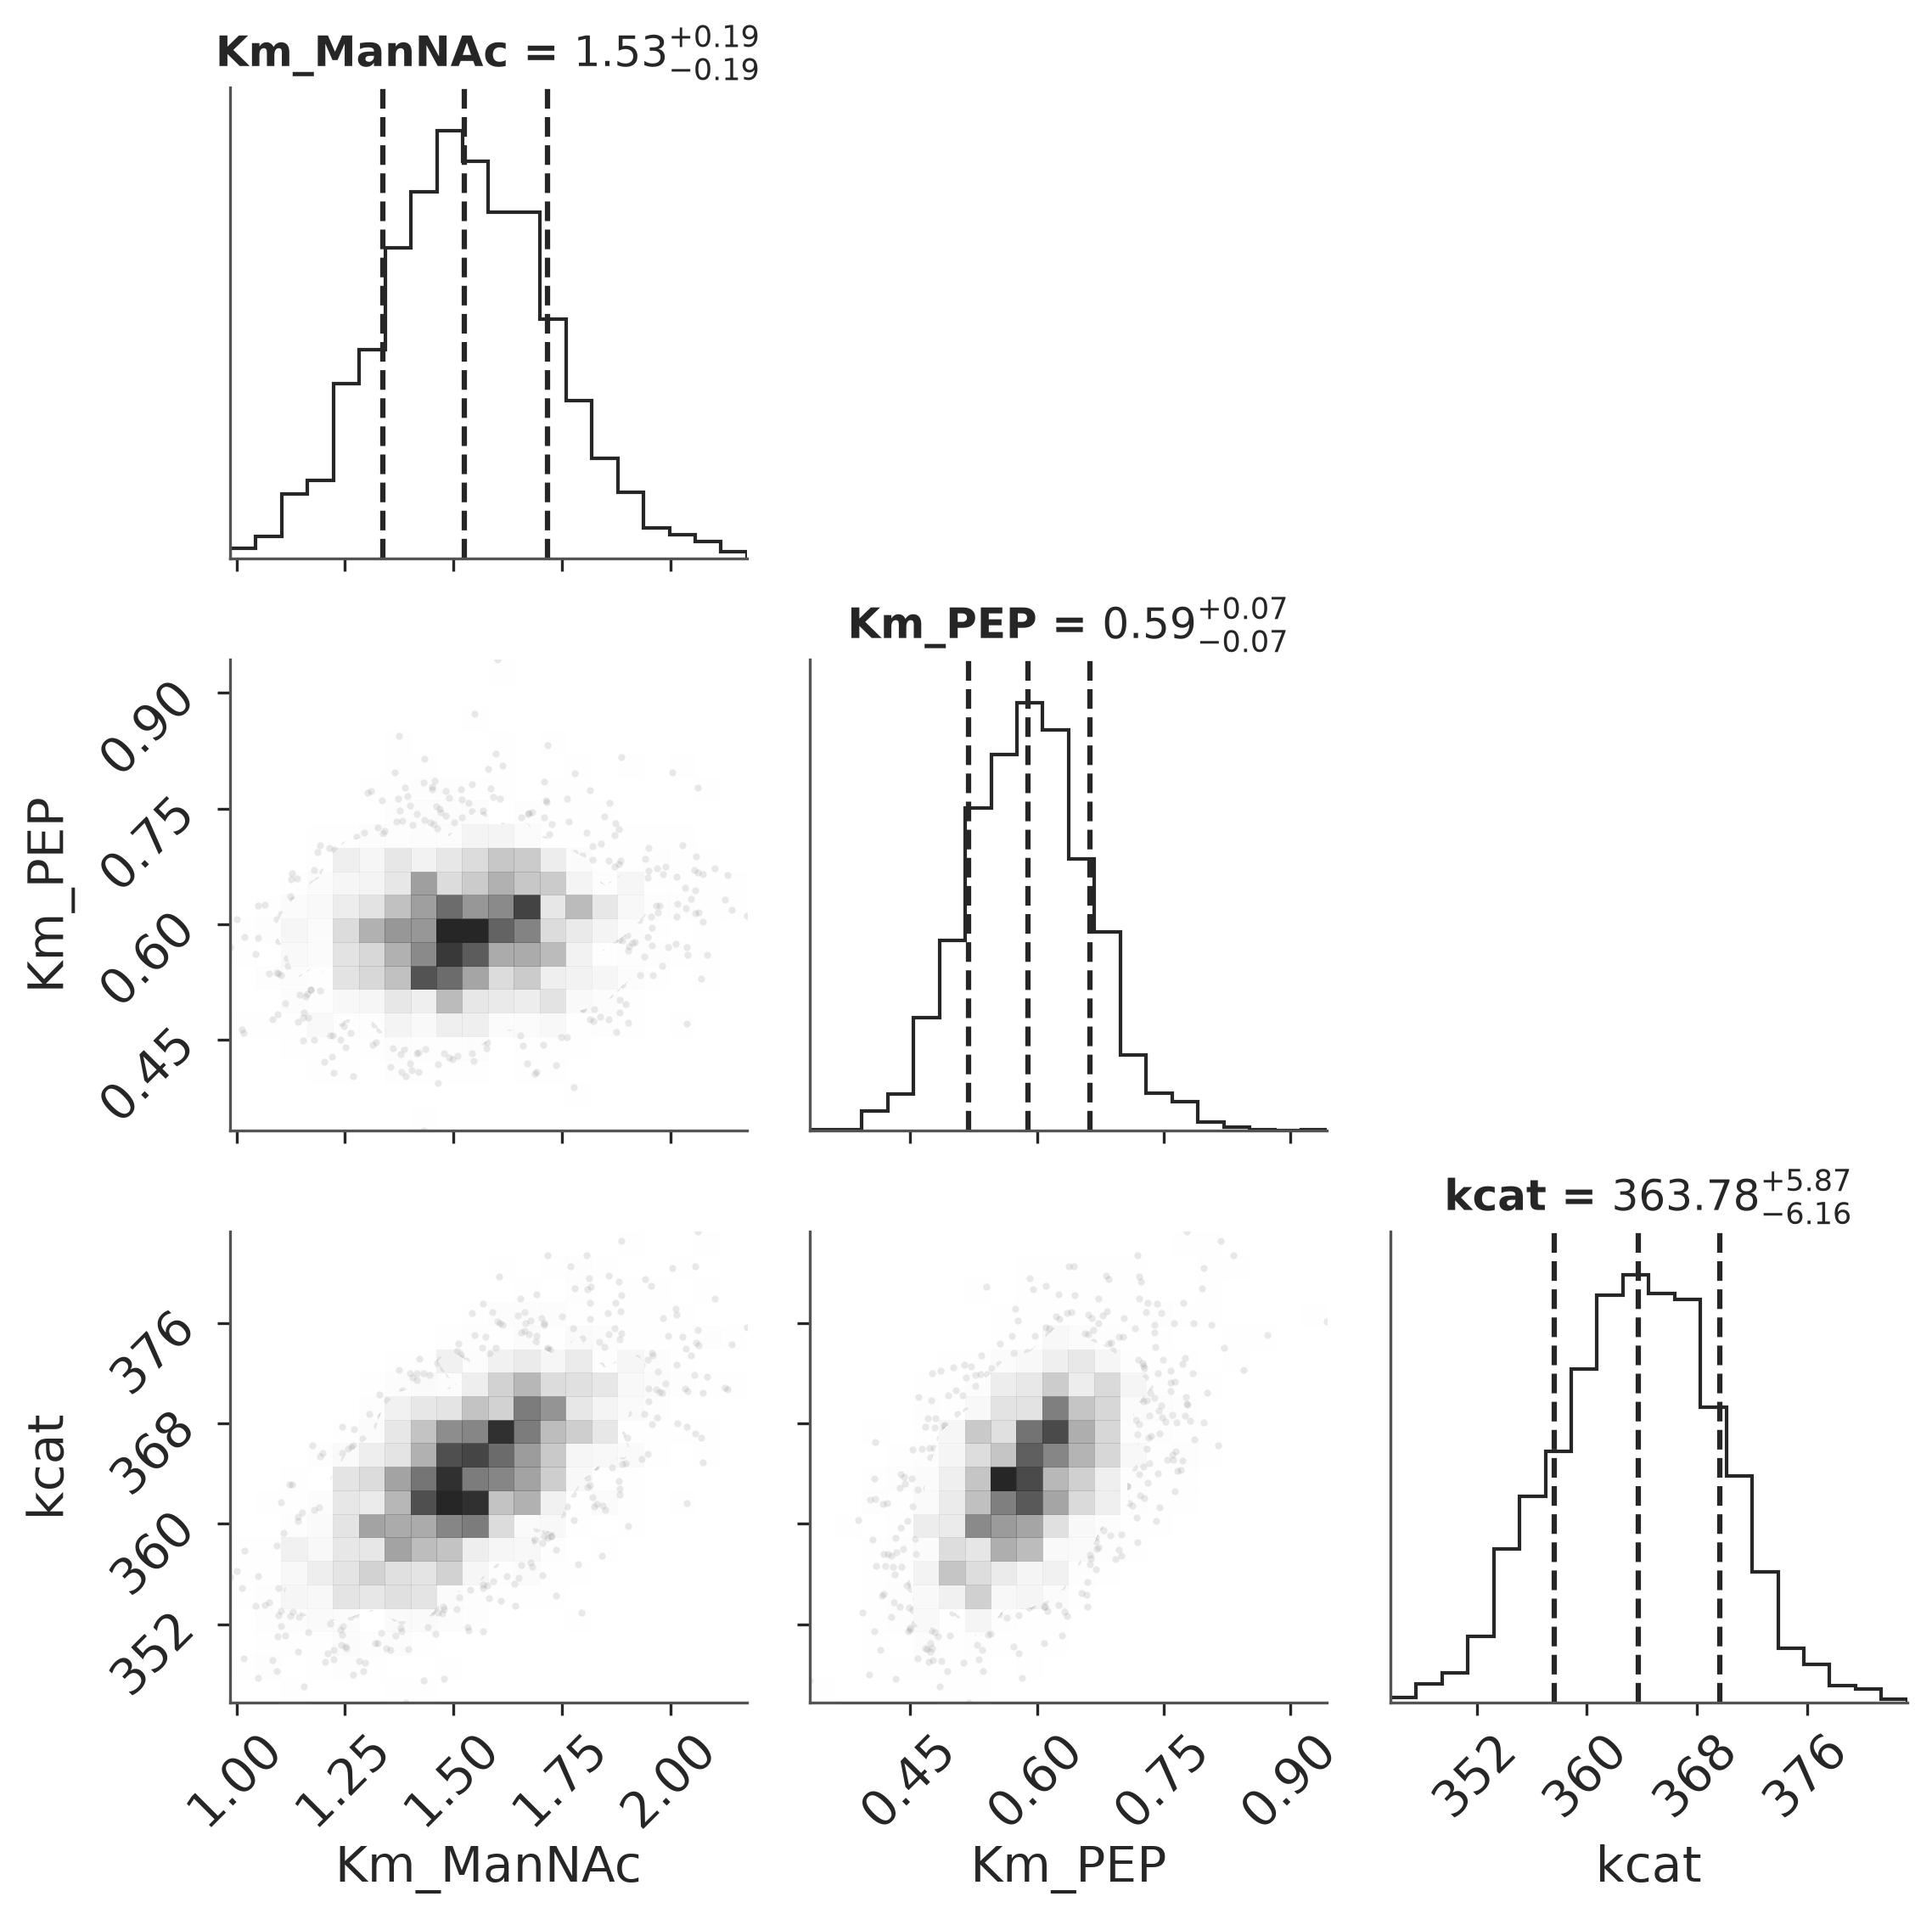

In [9]:
fig = results.plot_corner()
fig.savefig(ROOT / "slides" / "figures" / "corner.png", dpi=200, bbox_inches="tight")

## 4 · Does the model describe the data?

The model gets the posterior means as parameter values; `Dataset.plot` draws the data and,
with `predictor`, the model on top, one panel per reaction.

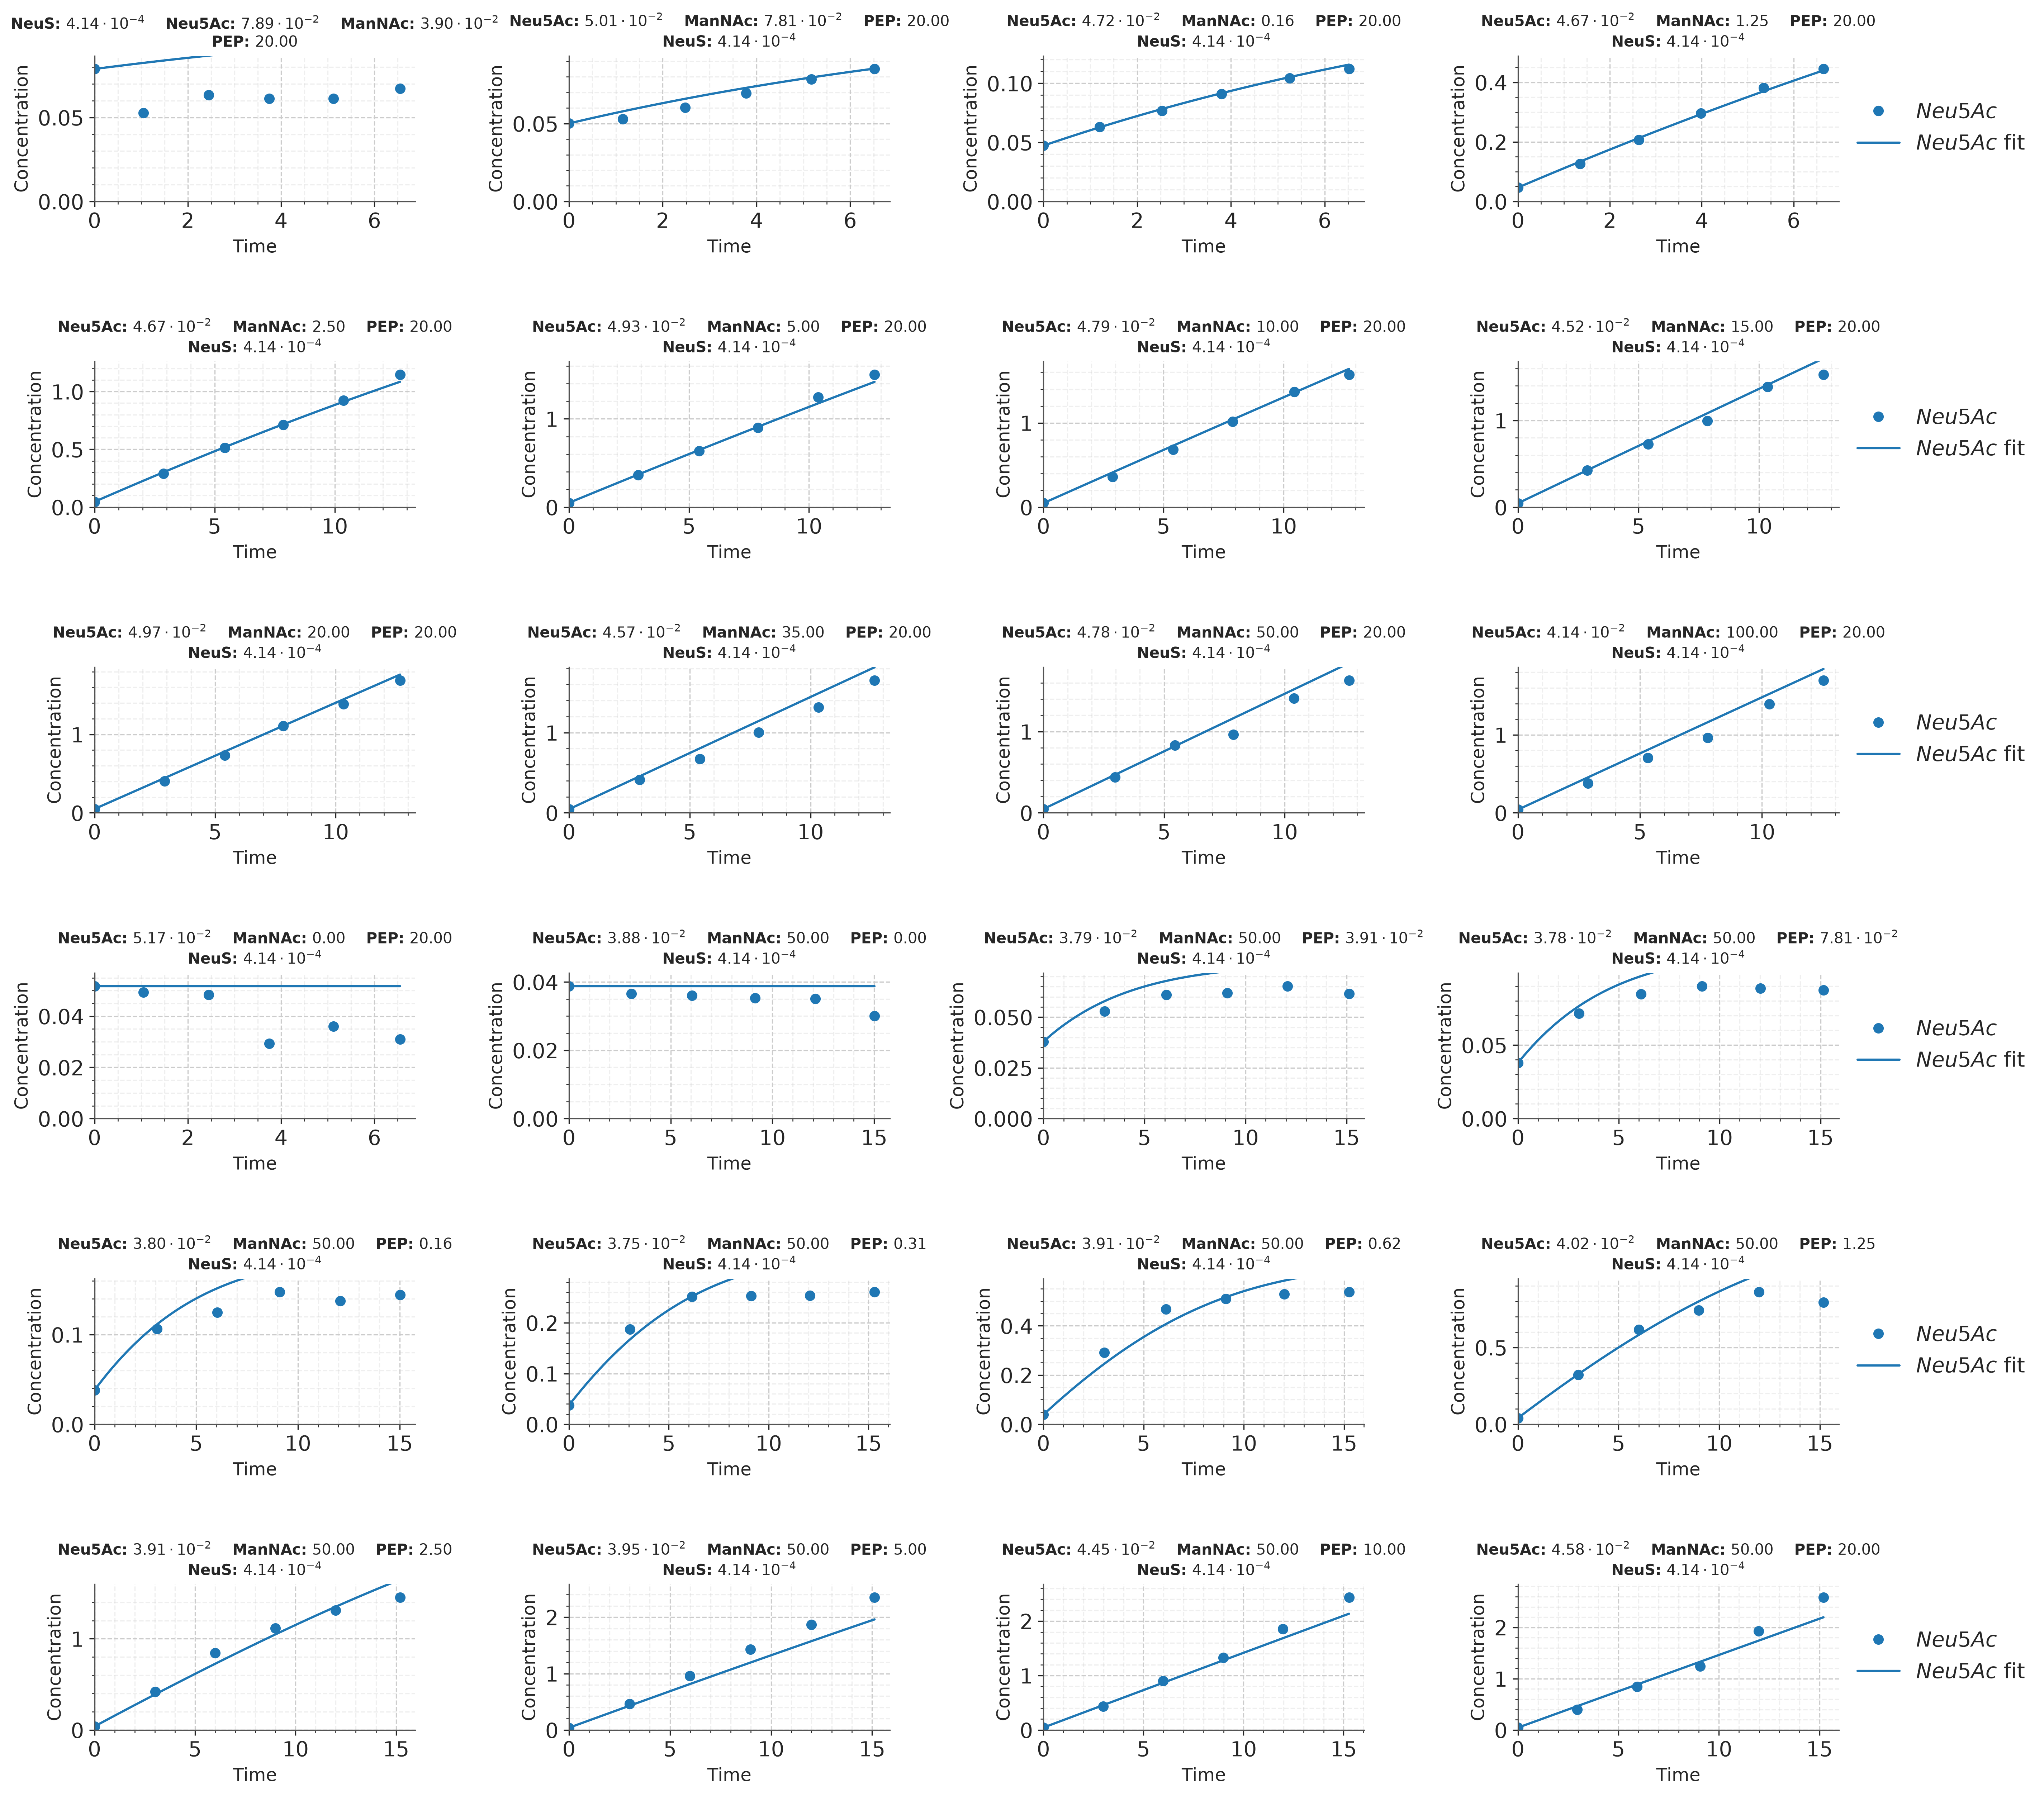

In [10]:
for name in PRIORS:
    model.parameters[name].value = float(posterior[name].mean())

fig = measured.plot(predictor=model, ncols=4, figsize=(4.8, 2.8))

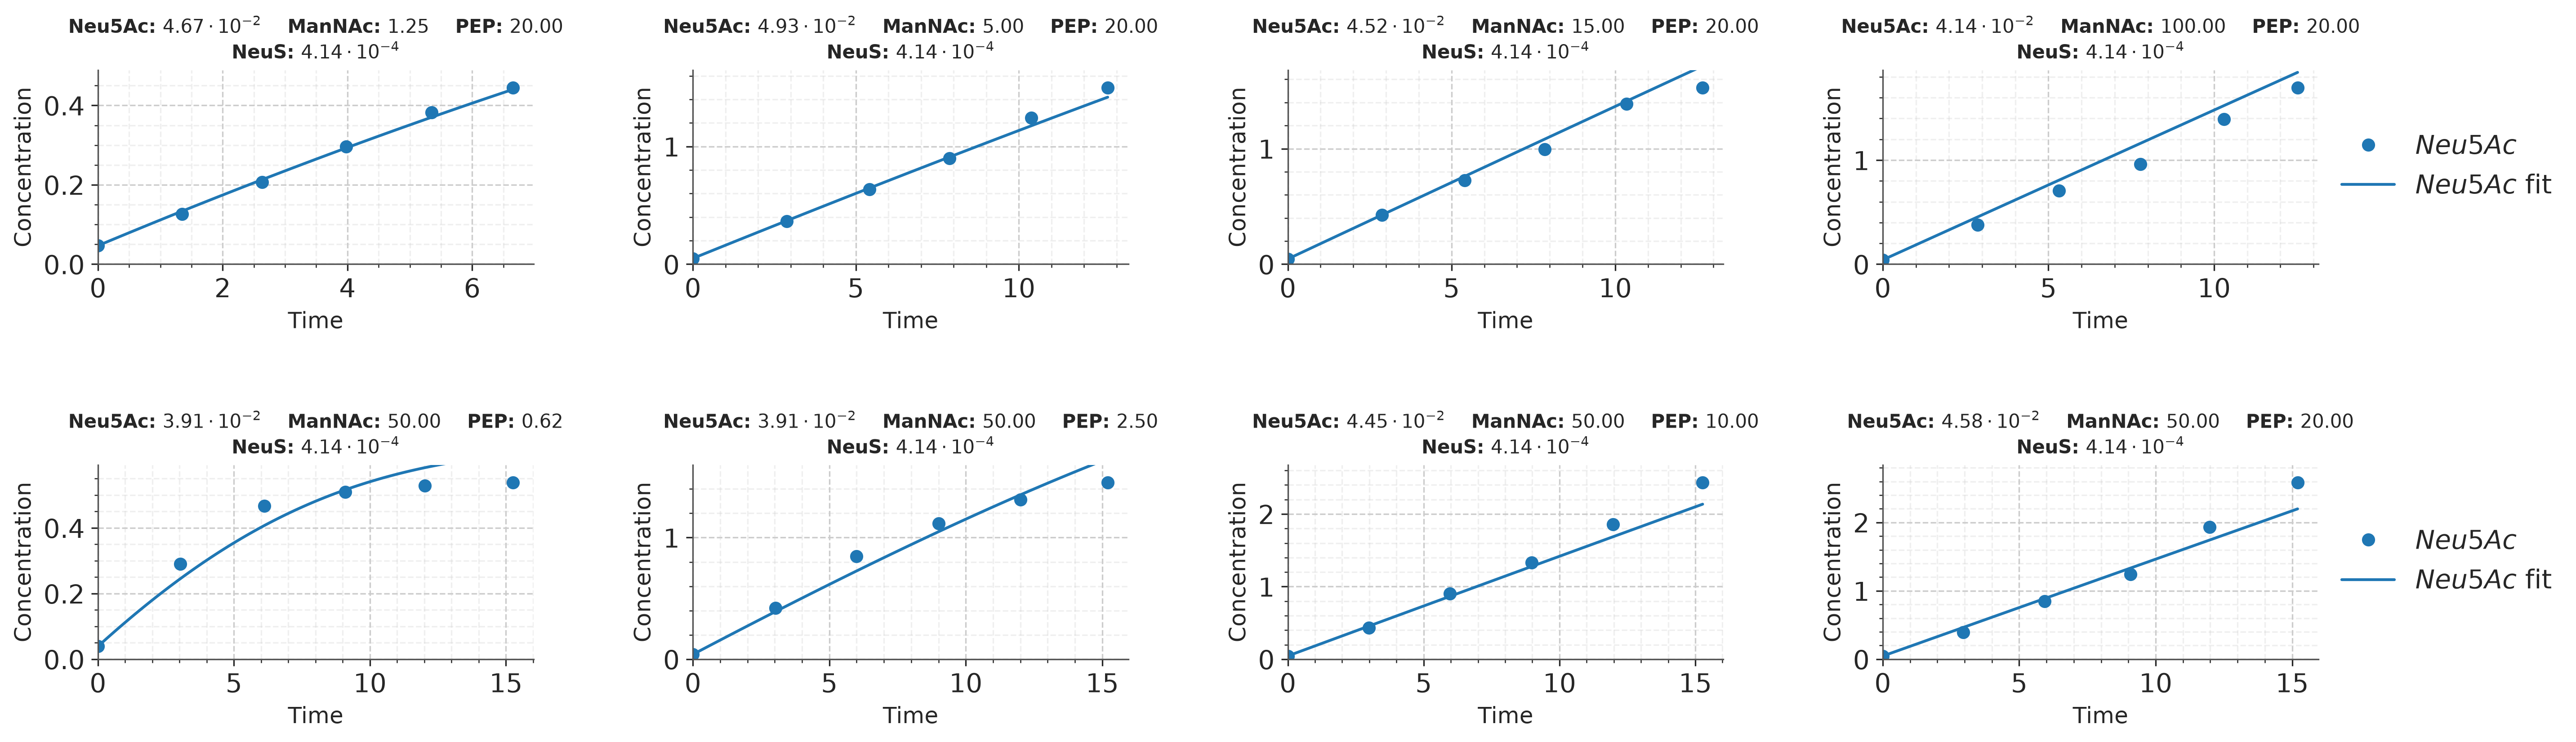

In [11]:
# A subset for the slides: four reactions of each series
SLIDE_REACTIONS = ["MAN_D", "MAN_F", "MAN_H", "MAN_L", "PEP_L", "PEP_N", "PEP_P", "PEP_R"]
fig = measured.plot(predictor=model, measurement_ids=SLIDE_REACTIONS, ncols=4, figsize=(4.8, 2.8))
fig.savefig(ROOT / "slides" / "figures" / "model_fit.png", dpi=200, bbox_inches="tight")

One shared `kcat` over-predicts the ManNAc series and under-predicts the PEP series: the two
series were measured on different days and differ in enzyme activity. A good question for the
discussion.